In [1]:
pip install torch pandas numpy matplotlib scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.1.1
[notice] To update, run: C:\Users\PRATYUSH\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


cuda


C:\Users\PRATYUSH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\torch\nn\modules\loss.py:608: UserWarning: Using a target size (torch.Size([7968])) that is different to the input size (torch.Size([7968, 1])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)


Epoch 1, Loss: 0.14798307418823242
Epoch 2, Loss: 0.1524846851825714
Epoch 3, Loss: 0.13163839280605316
Epoch 4, Loss: 0.13519874215126038
Epoch 5, Loss: 0.1345936506986618
Epoch 6, Loss: 0.13261833786964417
Epoch 7, Loss: 0.13114629685878754
Epoch 8, Loss: 0.130964457988739
Epoch 9, Loss: 0.13174377381801605
Epoch 10, Loss: 0.1317579448223114
Epoch 11, Loss: 0.13120487332344055
Epoch 12, Loss: 0.1308882087469101
Epoch 13, Loss: 0.13091298937797546
Epoch 14, Loss: 0.13108275830745697
Epoch 15, Loss: 0.1312154233455658
Epoch 16, Loss: 0.13123281300067902
Epoch 17, Loss: 0.1311456710100174
Epoch 18, Loss: 0.13101790845394135
Epoch 19, Loss: 0.13090865314006805
Epoch 20, Loss: 0.13085795938968658
Epoch 21, Loss: 0.1308716982603073
Epoch 22, Loss: 0.1309252381324768
Epoch 23, Loss: 0.13097327947616577
Epoch 24, Loss: 0.13098837435245514
Epoch 25, Loss: 0.13096235692501068
Epoch 26, Loss: 0.13091446459293365
Epoch 27, Loss: 0.1308717429637909
Epoch 28, Loss: 0.13085074722766876
Epoch 29, Lo

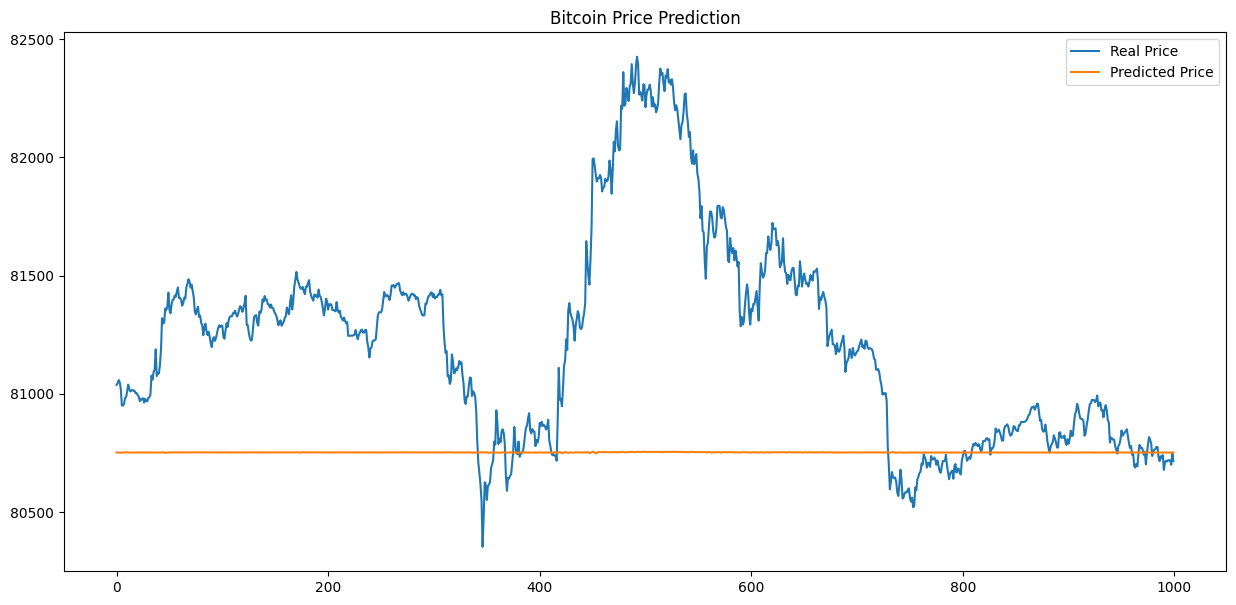

C:\Users\PRATYUSH\AppData\Local\Temp\ipykernel_23960\746093147.py:116: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  torch.load("bitcoin_lstm.pth"))


<All keys matched successfully>

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

df = pd.read_csv(r"C:\Users\PRATYUSH\OneDrive\Desktop\college\cses\btcusd_1-min_data.csv")
df = df.tail(10000)
df.dropna(inplace=True)
df['Timestamp'] = pd.to_datetime(df['Timestamp'], unit='s')
features = [
    'Open',
    'High',
    'Low',
    'Close',
    'Volume']
data = df[features].values

scaler = MinMaxScaler(feature_range=(-1, 1))
data_scaled = scaler.fit_transform(data)

sequence_length = 40
X = []
y = []
for i in range(sequence_length, len(data_scaled)):
    X.append(data_scaled[i-sequence_length:i])
    y.append(data_scaled[i,3])
X = np.array(X)
y = np.array(y)

split_index = int(len(X) * 0.8)
X_train = X[:split_index]
X_test = X[split_index:]
y_train = y[:split_index]
y_test = y[split_index:]

X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

X_train = X_train.to(device)
X_test = X_test.to(device)
y_train = y_train.to(device)
y_test = y_test.to(device)

class BitcoinLSTM(nn.Module):
    def __init__(self):
        super(BitcoinLSTM, self).__init__()
        self.lstm = nn.LSTM(
          input_size=5,
          hidden_size=128,
          num_layers=3,
          dropout=0.2,
          batch_first=True)
        self.fc = nn.Linear(128, 1)
    def forward(self, x):
        out, _ = self.lstm(x)
        out = out[:, -1, :]
        out = self.fc(out)
        return out

model = BitcoinLSTM()
model = model.to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.005
)
epochs=50

for epoch in range(epochs):
    model.train()
    outputs = model(X_train)
    loss = criterion(outputs, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    print(f"Epoch {epoch+1}, Loss: {loss.item()}")

model.eval()
with torch.no_grad():
  predictions = model(X_test)
  predictions = predictions.cpu().numpy()
  dummy_predictions = np.zeros((len(predictions), 5))
  dummy_predictions[:, 3] = predictions.flatten()
  predictions_inverse = scaler.inverse_transform(dummy_predictions)[:, 3]
  real_prices = y_test.cpu().numpy()
  dummy_real = np.zeros((len(real_prices), 5))
  dummy_real[:, 3] = real_prices.flatten()
  real_prices_inverse = scaler.inverse_transform(dummy_real)[:, 3]

from sklearn.metrics import mean_squared_error
rmse = np.sqrt(mean_squared_error(real_prices_inverse, predictions_inverse))
print("RMSE:", rmse)

plt.figure(figsize=(15,7))
plt.plot(real_prices_inverse[:1000], label="Real Price")
plt.plot(predictions_inverse[:1000], label="Predicted Price")
plt.legend()
plt.title("Bitcoin Price Prediction")
plt.show()

torch.save(
    model.state_dict(),
    "bitcoin_lstm.pth")
model = BitcoinLSTM()
model.load_state_dict(
    torch.load("bitcoin_lstm.pth"))